### 生成数据

In [17]:
import csv
import random
import math

# 用户输入
number = int(input("请输入试验次数: "))
money = float(input("请输入总金额: "))
people = int(input("请输入人数: "))

# 检查人数是否过多
if people > money * 100:
    print("people is too many")
else:
    # 创建CSV文件
    with open('envelopes.csv', 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        
        # 写入表头
        header = ['Trial'] + [f'Person{p}' for p in range(1, people + 1)]
        writer.writerow(header)
        
        # 存储所有试验结果
        all_results = []
        
        # 执行number次试验
        for j in range(number):
            envelopes = []
            remaining_money = money
            
            for i in range(people):
                # 计算剩余人数
                remaining_people = people - i
                
                # 计算剩余钱的平均值
                avg_money = remaining_money / remaining_people
                
                # 计算最大可分配金额
                max_possible_avg = min(avg_money * 2, 
                                     remaining_money - (remaining_people - 1) * 0.01)
                min_amount = 0.01
                max_amount = max(max_possible_avg, min_amount)
                
                # 如果是最后一个人，给他所有剩余的钱
                if i == people - 1:
                    money_get = round(remaining_money, 2)
                else:
                    # 生成随机金额
                    money_get = random.uniform(min_amount, max_amount)
                    money_get = round(money_get, 2)
                
                envelopes.append(money_get)
                remaining_money -= money_get
                # 由于浮点数精度问题，确保remaining_money保持两位小数
                remaining_money = round(remaining_money, 2)
            
            # 写入当前试验结果
            row = [j + 1] + envelopes
            writer.writerow(row)
            all_results.append(envelopes)
        
        # 写入总计行（每个人的总金额）
        total_row = ['Total']
        for p in range(people):
            person_total = sum(all_results[j][p] for j in range(number))
            total_row.append(round(person_total, 2))
        writer.writerow(total_row)
        
    
    print("CSV文件已生成: envelopes.csv")

CSV文件已生成: envelopes.csv


### 导入数据
计算mean,variance,std,median,min，max

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取CSV数据
path = "envelopes.csv"
raw = pd.read_csv(path)

# 2. 按行读取数据
data = raw.iloc[1:number].reset_index(drop=True)

# 3. 位次列
pos_cols = data.columns[1:people+1]

# 4. 转成长表
long_df = data[pos_cols].melt(
    var_name="position",
    value_name="amount"
).dropna()

# 提取位次编号
long_df["pos_id"] = long_df["position"].str.extract(r"(\d+)").astype(int) 

# 5. 统计信息
stats = long_df.groupby("pos_id")["amount"].agg(
    mean="mean",
    variance="var",
    std="std",
    median="median",
    min="min",
    max="max"
)

print(stats)

              mean     variance        std  median   min     max
pos_id                                                          
1        99.868985  3373.947585  58.085692   99.81  0.01  199.98
2       100.028389  3387.850002  58.205240   99.89  0.04  221.71
3       100.626076  3401.218792  58.319969   98.50  0.03  245.29
4        99.899165  3521.588686  59.342975   98.04  0.03  272.74
5       100.198515  3678.265963  60.648709   97.34  0.03  304.58
6       100.580697  3815.870998  61.772737   96.77  0.02  350.39
7       100.385133  4202.967384  64.830297   94.64  0.07  350.50
8        99.926621  4536.679455  67.354877   90.28  0.02  434.23
9        99.691947  5763.863800  75.920115   83.22  0.05  600.31
10       98.794473  5801.150450  76.165284   81.98  0.01  519.32


#### 箱线图和散点图

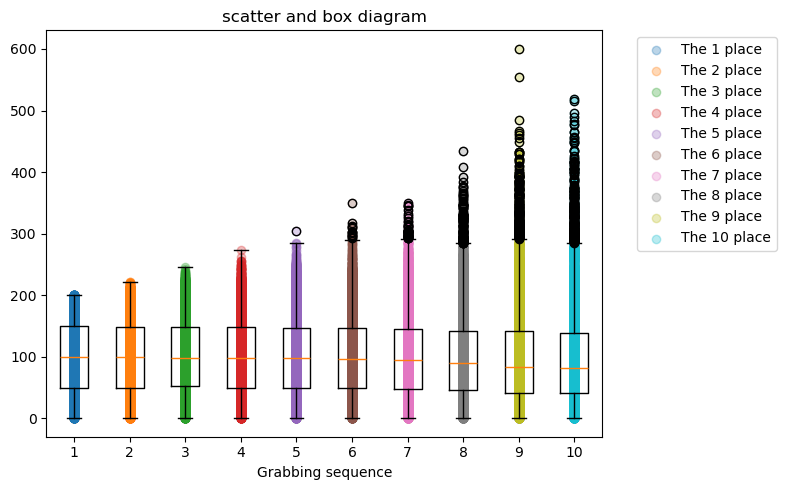

In [27]:
# 准备箱线图数据
box_data = [
    long_df[long_df["pos_id"] == pos]["amount"].values
    for pos in sorted(long_df["pos_id"].unique())
]
# 6. 散点图（不同位次不同颜色）
plt.figure(figsize=(8, 5))
plt.boxplot(box_data, showfliers=True)

for pos in sorted(long_df["pos_id"].unique()):
    y = long_df[long_df["pos_id"] == pos]["amount"]
    x = np.full(len(y), pos)
    plt.scatter(x, y, alpha=0.3, label=f"The {pos} place")

plt.xlabel("Grabbing sequence")
plt.ylabel("")
plt.title("scatter and box diagram")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### 画直方图（看分布形态）

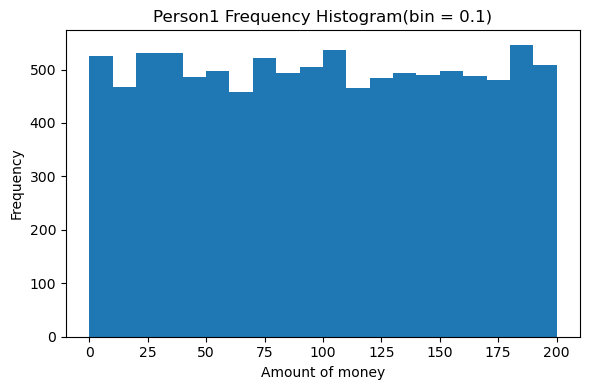

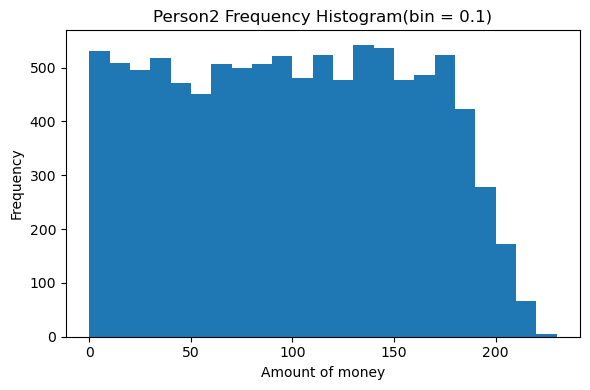

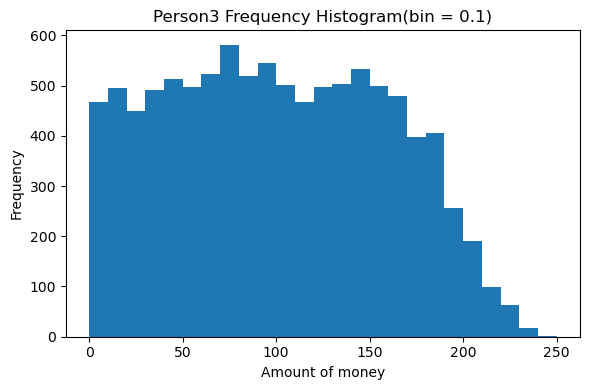

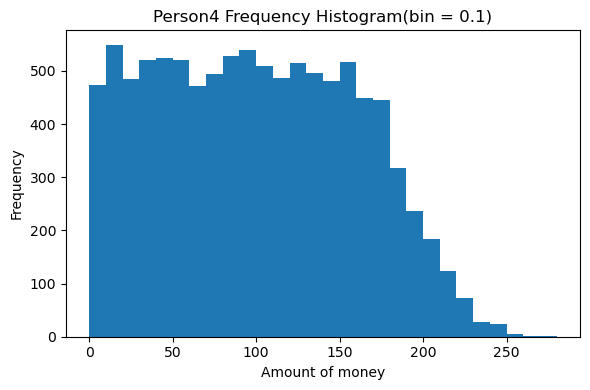

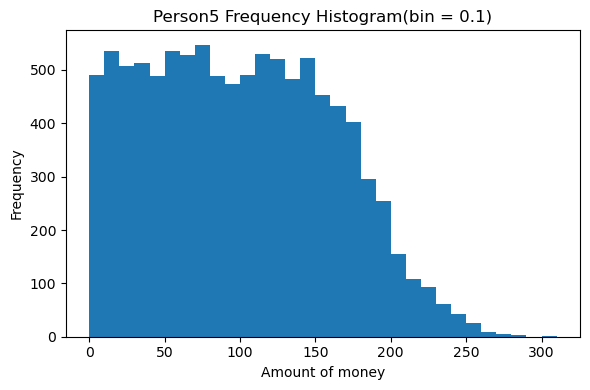

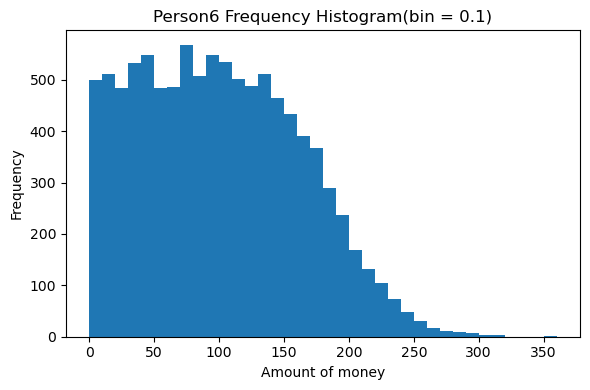

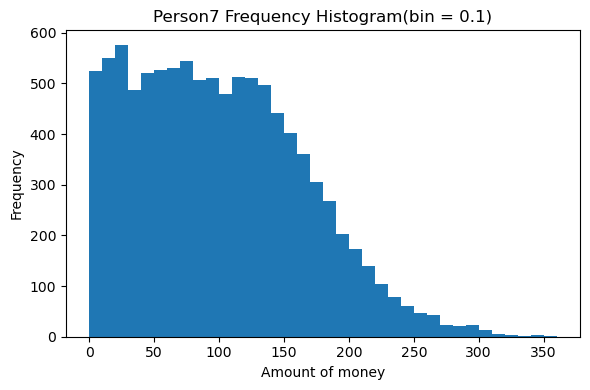

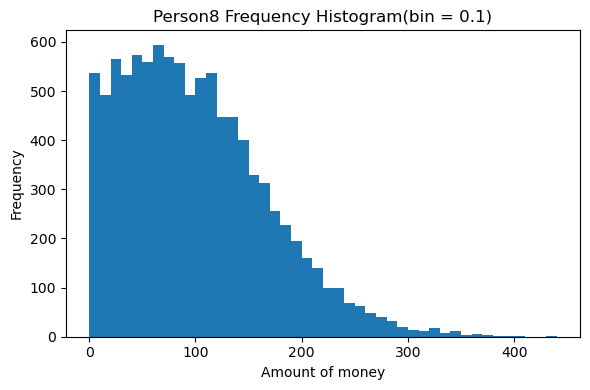

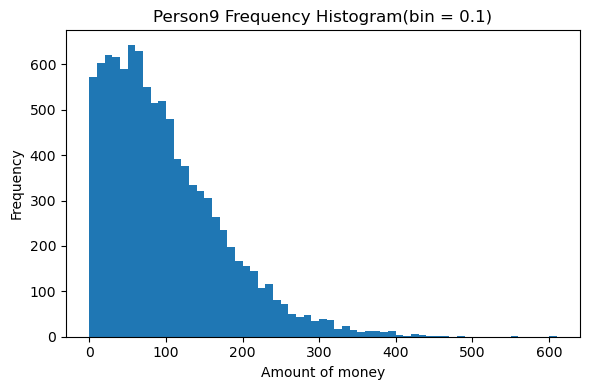

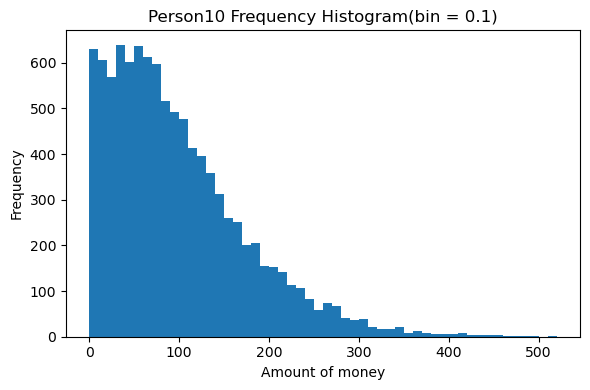

                bin_left  bin_right  count
position index                            
Person1  0           0.0       10.0    525
         1          10.0       20.0    467
         2          20.0       30.0    530
         3          30.0       40.0    530
         4          40.0       50.0    486


In [24]:
# 4. 直方图区间宽度
bin_width = 10

# 用于保存所有位次的频数统计结果
hist_tables = {}

for col in pos_cols:
    values = data[col].dropna().values
    
    # 构造 bins
    max_val = values.max()
    bins = np.arange(0, max_val + bin_width, bin_width)
    
    # 计算直方图频数
    counts, edges = np.histogram(values, bins=bins)
    
    # 记录频数表
    hist_df = pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "count": counts
    })
    hist_tables[col] = hist_df
    
    # 绘制直方图
    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=bins)
    plt.xlabel("Amount of money")
    plt.ylabel("Frequency")
    plt.title(f"{col} Frequency Histogram(bin = 0.1)")
    plt.tight_layout()
    plt.show()

# 5. 合并所有位次的频数统计（方便统一分析）
all_hist_table = pd.concat(
    hist_tables,
    names=["position", "index"]
)

print(all_hist_table.head())